<a href="https://colab.research.google.com/github/ashwini-ah18/Artificial-Intelligence/blob/main/Binary_classificaton_with_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Binary classificaton with keras

## Build a model that can predict the status of train booking


In [1]:
path = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/booking_train.csv"
import pandas as pd
df = pd.read_csv(path)
df.head()


,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


## Perform basic data quality checks


In [2]:

df.shape


(42100, 19)

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42100 entries, 0 to 42099
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    42100 non-null  int64  
 1   no_of_adults                          42100 non-null  int64  
 2   no_of_children                        42100 non-null  int64  
 3   no_of_weekend_nights                  42100 non-null  int64  
 4   no_of_week_nights                     42100 non-null  int64  
 5   type_of_meal_plan                     42100 non-null  int64  
 6   required_car_parking_space            42100 non-null  int64  
 7   room_type_reserved                    42100 non-null  int64  
 8   lead_time                             42100 non-null  int64  
 9   arrival_year                          42100 non-null  int64  
 10  arrival_month                         42100 non-null  int64  
 11  arrival_date   

In [4]:

df.duplicated().sum()

np.int64(0)

In [5]:

df.isna().sum()

,0
id,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


# Separate X and Y features

X : all the features except id and booking_status Y : booking_status

In [6]:

X = df.drop(columns=['id','booking_status'])
Y = df[['booking_status']]

In [7]:
X.head()


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0
1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0
2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0
3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0
4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0


In [8]:
Y.head()

,booking_status
0,0
1,0
2,0
3,0
4,1


In [9]:

Y['booking_status'].value_counts()

,count
booking_status,
0,25596
1,16504


In [10]:

(Y['booking_status'].value_counts()/len(Y))*100

,count
booking_status,
0,60.7981
1,39.2019


## Splitting of the data into training and testing

In [11]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,test_size=0.2,random_state=21)
print(xtrain.shape,xtest.shape,ytrain.shape,ytest.shape)


(33680, 17) (8420, 17) (33680, 1) (8420, 1)


## Data cleaning and preprocessing

In [12]:

xtrain.dtypes

,0
no_of_adults,int64
no_of_children,int64
no_of_weekend_nights,int64
no_of_week_nights,int64
type_of_meal_plan,int64
required_car_parking_space,int64
room_type_reserved,int64
lead_time,int64
arrival_year,int64
arrival_month,int64


In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = make_pipeline(SimpleImputer(strategy='mean'),
                         StandardScaler()).set_output(transform='pandas')
num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler())])

In [14]:
num_pipe.fit(xtrain)


Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler())])

In [15]:
xtrain_pre = num_pipe.transform(xtrain)
xtest_pre = num_pipe.transform(xtest)


In [16]:
xtrain_pre.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
17408,0.151436,-0.312673,1.256274,0.419186,-0.408159,-0.160128,-0.511693,0.624659,0.409563,0.141659,-1.000048,-1.140519,-0.173662,-0.060418,-0.102335,-0.861405,0.550799
24897,0.151436,-0.312673,0.127732,-0.279215,1.287510,-0.160128,-0.511693,0.058875,0.409563,0.141659,-0.775040,0.426258,-0.173662,-0.060418,-0.102335,0.072258,0.550799
18155,-1.754525,-0.312673,0.127732,-0.279215,-0.408159,-0.160128,-0.511693,-1.281789,0.409563,-1.627370,0.124990,-1.140519,-0.173662,-0.060418,-0.102335,-0.747544,-0.738085
22920,-1.754525,-0.312673,-1.000811,1.117587,-0.408159,-0.160128,-0.511693,-0.433112,0.409563,-0.565953,1.362532,0.426258,-0.173662,-0.060418,-0.102335,0.417861,-0.738085
18137,0.151436,-0.312673,0.127732,-0.279215,-0.408159,-0.160128,-0.511693,-0.543809,0.409563,-1.273564,1.025021,-1.140519,-0.173662,-0.060418,-0.102335,-0.787730,-0.738085


## Model Buidling : ANN model

In [17]:
xtrain.shape

(33680, 17)

In [18]:

xtrain.shape[1]

17

In [19]:

ytrain['booking_status'].value_counts()

,count
booking_status,
0,20500
1,13180


In [20]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout

# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer
model.add(Dense(units=64,activation='relu'))
# Add the Dropout layer
model.add(Dropout(rate=0.3))

# Add the Hidden layer
model.add(Dense(units=32,activation='relu'))
# Add the Dropout layer
model.add(Dropout(rate=0.15))

# Add the output layer
model.add(Dense(units=1,activation='sigmoid'))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:

# backpropagation
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [23]:


nn = model.fit(xtrain_pre,ytrain,epochs=35,validation_split=0.2)
# validation_split takes 20% of training data for evaluation

Epoch 1/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7442 - loss: 0.5178 - val_accuracy: 0.7749 - val_loss: 0.4668
Epoch 2/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7738 - loss: 0.4794 - val_accuracy: 0.7834 - val_loss: 0.4612
Epoch 3/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7831 - loss: 0.4674 - val_accuracy: 0.7847 - val_loss: 0.4556
Epoch 4/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7834 - loss: 0.4665 - val_accuracy: 0.7877 - val_loss: 0.4552
Epoch 5/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7878 - loss: 0.4612 - val_accuracy: 0.7892 - val_loss: 0.4523
Epoch 6/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7889 - loss: 0.4598 - val_accuracy: 0.7919 - val_loss: 0.4506
Epoch 7/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7904 - loss: 0.4554 - val_accuracy: 0.7910 - val_loss: 0.4501
Epoch 8/35
842/842 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7935 - loss: 0.4535 - val_accuracy: 0.

## Learning curve

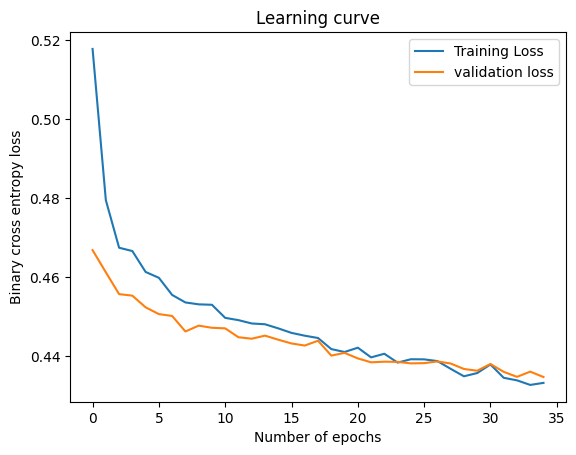

In [24]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label="Training Loss")
plt.plot(nn.history['val_loss'],label ="validation loss")
plt.title("Learning curve")
plt.xlabel("Number of epochs")
plt.ylabel("Binary cross entropy loss")
plt.legend()
plt.show()

## Model evaluation

In [25]:

model.evaluate(xtrain_pre,ytrain)

1053/1053 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8132 - loss: 0.4197


[0.4197341799736023, 0.8131532073020935]

In [26]:

model.evaluate(xtest_pre,ytest)

264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7990 - loss: 0.4433


[0.4433234930038452, 0.7990498542785645]

## Cassification report and confusion matrix

In [27]:

from sklearn.metrics import classification_report,confusion_matrix
ypred = model.predict(xtest_pre)
ypred = (ypred>0.5).astype(int)
print(ypred[:5])

264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[0]
 [1]
 [0]
 [0]
 [0]]


In [28]:
ytest.head(5)

,booking_status
20351,0
21728,0
12697,1
20136,0
27760,0


In [29]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      5096
           1       0.77      0.71      0.74      3324

    accuracy                           0.80      8420
   macro avg       0.79      0.78      0.79      8420
weighted avg       0.80      0.80      0.80      8420



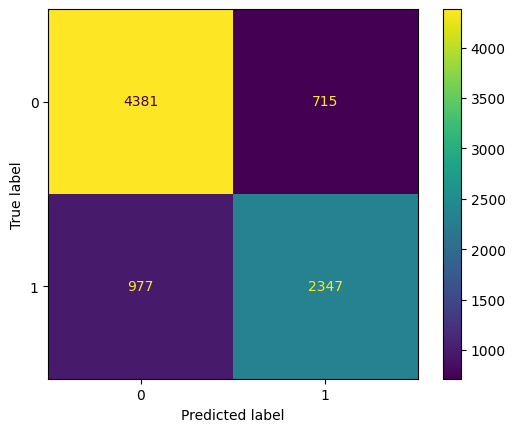

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(ytest,ypred)


#Considering the model's microavg f1 score closer to 80, we can finalize this model.

#If you want to get better scores, you can try modifying below hyperparameters:

YOU MUST RESTART THE RUNTIME AND RUN ALL THE CELLS.

EPochs
Validation_split
Dropout layer - units
Hidden layer - units
Number of hidden layers required

#Save your models and save your pipeline

In [31]:

model.save("BookingStatusModel.keras")

In [32]:

import joblib
joblib.dump(num_pipe,"preprocessor.joblib")

['preprocessor.joblib']

## Perform new data predictions

##Load the model and preprocessor

In [33]:
from keras.models import load_model
from joblib import load

model_loaded = load_model(r"/content/BookingStatusModel.keras")

pre_loaded = load(r"/content/preprocessor.joblib")

In [34]:

model_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,797 (38.27 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,532 (25.52 KB)

In [35]:

pre_loaded

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler())])

In [36]:
path2 = r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/booking_test.csv"
sample = pd.read_csv(path2)
sample

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,42100,3,0,1,4,0,0,1,111,2018,12,5,1,0,0,0,115.60,2
1,42101,2,0,0,3,0,0,0,22,2017,10,21,0,0,0,0,85.00,0
2,42102,2,2,0,1,0,0,3,18,2018,8,10,1,0,0,0,240.00,1
3,42103,2,0,0,3,0,0,0,88,2018,5,30,0,0,0,0,80.75,0
4,42104,1,0,0,2,2,0,0,7,2018,9,21,1,0,0,0,144.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28063,70163,2,0,1,2,0,0,0,315,2018,9,30,1,0,0,0,160.00,0
28064,70164,2,0,2,2,0,0,0,81,2018,3,25,0,0,0,0,65.00,1
28065,70165,2,0,1,2,0,0,0,40,2018,10,22,0,0,0,0,85.00,0
28066,70166,3,0,0,4,0,0,1,4,2018,9,6,1,0,0,0,162.75,0


In [37]:

new_sample = sample.drop(columns='id')
new_sample


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,3,0,1,4,0,0,1,111,2018,12,5,1,0,0,0,115.60,2
1,2,0,0,3,0,0,0,22,2017,10,21,0,0,0,0,85.00,0
2,2,2,0,1,0,0,3,18,2018,8,10,1,0,0,0,240.00,1
3,2,0,0,3,0,0,0,88,2018,5,30,0,0,0,0,80.75,0
4,1,0,0,2,2,0,0,7,2018,9,21,1,0,0,0,144.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28063,2,0,1,2,0,0,0,315,2018,9,30,1,0,0,0,160.00,0
28064,2,0,2,2,0,0,0,81,2018,3,25,0,0,0,0,65.00,1
28065,2,0,1,2,0,0,0,40,2018,10,22,0,0,0,0,85.00,0
28066,3,0,0,4,0,0,1,4,2018,9,6,1,0,0,0,162.75,0


In [38]:

new_sample_pre = pre_loaded.transform(new_sample)
new_sample_pre

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2.057396,-0.312673,0.127732,1.117587,-0.408159,-0.160128,0.692123,0.083474,0.409563,1.556882,-1.225056,0.426258,-0.173662,-0.060418,-0.102335,0.299981,1.839684
1,0.151436,-0.312673,-1.000811,0.419186,-0.408159,-0.160128,-0.511693,-1.011196,-2.441629,0.849270,0.575005,-1.140519,-0.173662,-0.060418,-0.102335,-0.519821,-0.738085
2,0.151436,4.173298,-1.000811,-0.977616,-0.408159,-0.160128,3.099754,-1.060395,0.409563,0.141659,-0.662537,0.426258,-0.173662,-0.060418,-0.102335,3.632770,0.550799
3,0.151436,-0.312673,-1.000811,0.419186,-0.408159,-0.160128,-0.511693,-0.199418,0.409563,-0.919758,1.587540,-1.140519,-0.173662,-0.060418,-0.102335,-0.633683,-0.738085
4,-1.754525,-0.312673,-1.000811,-0.279215,2.983179,-0.160128,-0.511693,-1.195691,0.409563,0.495465,0.575005,0.426258,-0.173662,-0.060418,-0.102335,1.060842,-0.738085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28063,0.151436,-0.312673,0.127732,-0.279215,-0.408159,-0.160128,-0.511693,2.592605,0.409563,0.495465,1.587540,0.426258,-0.173662,-0.060418,-0.102335,1.489497,-0.738085
28064,0.151436,-0.312673,1.256274,-0.279215,-0.408159,-0.160128,-0.511693,-0.285516,0.409563,-1.627370,1.025021,-1.140519,-0.173662,-0.060418,-0.102335,-1.055639,0.550799
28065,0.151436,-0.312673,0.127732,-0.279215,-0.408159,-0.160128,-0.511693,-0.789802,0.409563,0.849270,0.687509,-1.140519,-0.173662,-0.060418,-0.102335,-0.519821,-0.738085
28066,2.057396,-0.312673,-1.000811,1.117587,-0.408159,-0.160128,0.692123,-1.232590,0.409563,0.495465,-1.112552,0.426258,-0.173662,-0.060418,-0.102335,1.563172,-0.738085


In [39]:

preds = model_loaded.predict(new_sample_pre)
preds = (preds>0.5).astype(int)
print(preds[:5])

878/878 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
[[0]
 [0]
 [0]
 [0]
 [1]]


In [40]:
sample.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,42100,3,0,1,4,0,0,1,111,2018,12,5,1,0,0,0,115.60,2
1,42101,2,0,0,3,0,0,0,22,2017,10,21,0,0,0,0,85.00,0
2,42102,2,2,0,1,0,0,3,18,2018,8,10,1,0,0,0,240.00,1
3,42103,2,0,0,3,0,0,0,88,2018,5,30,0,0,0,0,80.75,0
4,42104,1,0,0,2,2,0,0,7,2018,9,21,1,0,0,0,144.00,0


In [41]:
sample['BookingStatusPredicted'] = preds
sample.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,BookingStatusPredicted
0,42100,3,0,1,4,0,0,1,111,2018,12,5,1,0,0,0,115.60,2,0
1,42101,2,0,0,3,0,0,0,22,2017,10,21,0,0,0,0,85.00,0,0
2,42102,2,2,0,1,0,0,3,18,2018,8,10,1,0,0,0,240.00,1,0
3,42103,2,0,0,3,0,0,0,88,2018,5,30,0,0,0,0,80.75,0,0
4,42104,1,0,0,2,2,0,0,7,2018,9,21,1,0,0,0,144.00,0,1


In [42]:
sample.to_csv("PRedictionsDone.csv",index=False)